# Import

In [22]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import AutoTokenizer
import transformers
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [74]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.dataset import NLIDataset
from src.model import get_model

In [75]:
MAX_LENGTH = 128
MODEL_NAME = "vinai/phobert-base"
BATCH_SIZE = 32
transformers.logging.set_verbosity_error()

# Inference

In [76]:
device = torch.device("cpu")
device

device(type='cpu')

In [77]:
splits = {'train': 'vianli_train.jsonl', 'validation': 'vianli_dev.jsonl', 'test': 'vianli_test.jsonl'}
df_test = pd.read_json("hf://datasets/uitnlp/ViANLI/" + splits["test"], lines=True)
df_test.head(5)

,uid,premise,hypothesis,label
0,uit_Adver_2078_2_21_11,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND ph...",Theo thông tin một công chức Nhà nước ở phường...,contradiction
1,uit_Adver_1669_2_21_09,Cảnh sát thành phố Bhopal hôm 13/5 cho biết sự...,Sự việc gây sốc xảy ra đầu tháng 4 và nghi phạ...,contradiction
2,uit_Adver_712_2_11_04,"Ngày 2/5, sinh nhật tuổi 49 của The Rock, tài ...",Cung hoàng đạo của The Rock là Kim Ngưu.,entailment
3,uit_Adver_1663_3_31_09,"Sau khi xem xét camera giám sát trong khu vực,...",Cảnh sát đã phán đoán bằng nhận định sắc bén s...,neutral
4,uit_Adver_1561_4_21_08,"3h sáng cùng ngày, trái tim của của người hiến...","3am, một người được tái sinh.",contradiction


In [78]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, num_labels=len(df_test["label"].unique()))

test_dataset = NLIDataset(test_df, tokenizer, max_length=MAX_LENGTH)

test_dataloader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)
len(test_dataloader)

32

In [79]:
model = get_model(MODEL_NAME, num_labels=len(df_test["label"].unique()))
model.load_state_dict(torch.load("../model/best_model.pth", map_location=device))
model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(258, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [80]:
print("Start inferencing...")
all_probs = []
all_preds = []
with torch.inference_mode(): 
    for batch in tqdm(test_dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids = input_ids, attention_mask = attention_mask)
        logits = outputs.logits

        probs = torch.softmax(logits, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())

Start inferencing...


100%|██████████| 32/32 [01:11<00:00,  2.25s/it]


In [81]:
all_preds[:5], all_probs[:5]

([np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1)],
 [np.float32(0.7809924),
  np.float32(0.7261206),
  np.float32(0.50167453),
  np.float32(0.7638649),
  np.float32(0.82904613)])

In [82]:
df_test["predicted_labels"] = all_preds
df_test["confidence_score"] = all_probs

reverse_map = {v: k for k, v in test_dataset.label_dict.items()}

df_test["predicted_labels_text"] = df_test["predicted_labels"].map(reverse_map)
df_test.head(10)

,uid,premise,hypothesis,label,predicted_labels,confidence_score,predicted_labels_text
0,uit_Adver_2078_2_21_11,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND ph...",Theo thông tin một công chức Nhà nước ở phường...,contradiction,1,0.780992,entailment
1,uit_Adver_1669_2_21_09,Cảnh sát thành phố Bhopal hôm 13/5 cho biết sự...,Sự việc gây sốc xảy ra đầu tháng 4 và nghi phạ...,contradiction,0,0.726121,contradiction
2,uit_Adver_712_2_11_04,"Ngày 2/5, sinh nhật tuổi 49 của The Rock, tài ...",Cung hoàng đạo của The Rock là Kim Ngưu.,entailment,1,0.501675,entailment
3,uit_Adver_1663_3_31_09,"Sau khi xem xét camera giám sát trong khu vực,...",Cảnh sát đã phán đoán bằng nhận định sắc bén s...,neutral,1,0.763865,entailment
4,uit_Adver_1561_4_21_08,"3h sáng cùng ngày, trái tim của của người hiến...","3am, một người được tái sinh.",contradiction,1,0.829046,entailment
5,uit_Adver_596_1_31_03,Sau khi trường Cao đẳng Sư phạm Ninh Thuận sáp...,Trường Cao đẳng Sư phạm Ninh Thuận sẽ mở thêm ...,neutral,0,0.558878,contradiction
6,uit_Adver_320_4_31_02,"Ông Phạm Cao Vỹ, chủ tịch Hiệp hội Du lịch Sa ...",Ông Phạm Cao Vỹ được yêu thích.,neutral,1,0.849779,entailment
7,uit_Adver_1595_1_31_08,Ngành y tế Quảng Nam ngày 16/5 ghi nhận 3.070 ...,Giữa tháng 5 số lượng mẫu âm tính tại Quảng Na...,neutral,1,0.698798,entailment
8,uit_Adver_1419_3_11_08,"Các bệnh nhân 3262, 3268, 3660 tiếp tục cách l...",Các bệnh nhận được quan sát điều trị trong vòn...,entailment,1,0.778693,entailment
9,uit_Adver_1479_5_11_08,"""Bệnh viện cũng chuẩn bị 20 hòm phiếu được dán...",20 thùng rỗng được đảm bảo cho cuộc bỏ phiếu.,entailment,0,0.663941,contradiction


In [101]:
df_test.to_csv("../data/test_predictions.csv", index=False)
print("Đã lưu toàn bộ kết quả dự đoán vào data/test_predictions.csv")

Đã lưu toàn bộ kết quả dự đoán vào data/test_predictions.csv


# Plot training error

In [41]:
with open("../model/history.json", "r") as f:
    history = json.load(f)

epochs = range(1, len(history["train_loss"]) + 1)
epochs

range(1, 17)

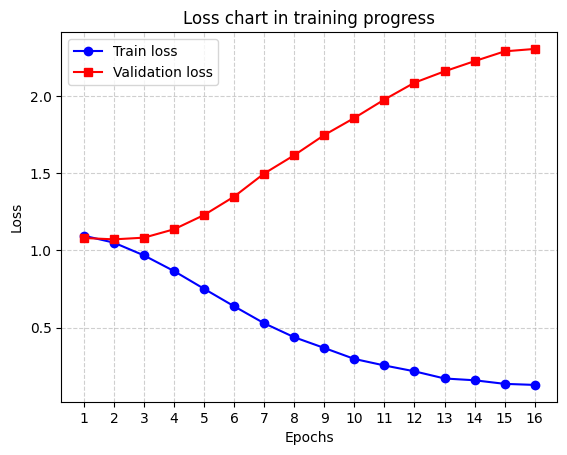

In [43]:
plt.plot(epochs, history["train_loss"], "b-o", label="Train loss")
plt.plot(epochs, history["val_loss"], "r-s", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss chart in training progress")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../data/loss_curves.png", dpi=300)
plt.show()


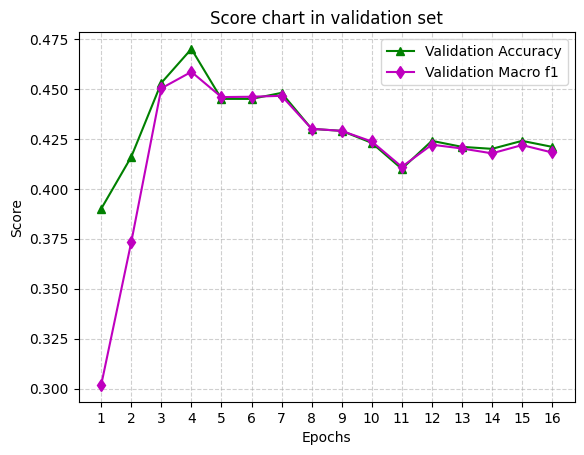

In [42]:
plt.plot(epochs, history["val_acc"], "g-^", label="Validation Accuracy")
plt.plot(epochs, history["val_f1"], "m-d", label="Validation Macro f1")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Score chart in validation set")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("../data/score_curves.png", dpi=300)
plt.show()

# Error Analysis

## Classification report

In [5]:
df_result = pd.read_csv("../data/test_predictions.csv")
dfresult = df_result.dropna(subset=['label', 'predicted_labels'])
df_result.head(5)

,uid,premise,hypothesis,label,predicted_labels,confidence_score,predicted_labels_text
0,uit_Adver_2078_2_21_11,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND ph...",Theo thông tin một công chức Nhà nước ở phường...,contradiction,1,0.780992,entailment
1,uit_Adver_1669_2_21_09,Cảnh sát thành phố Bhopal hôm 13/5 cho biết sự...,Sự việc gây sốc xảy ra đầu tháng 4 và nghi phạ...,contradiction,0,0.726121,contradiction
2,uit_Adver_712_2_11_04,"Ngày 2/5, sinh nhật tuổi 49 của The Rock, tài ...",Cung hoàng đạo của The Rock là Kim Ngưu.,entailment,1,0.501675,entailment
3,uit_Adver_1663_3_31_09,"Sau khi xem xét camera giám sát trong khu vực,...",Cảnh sát đã phán đoán bằng nhận định sắc bén s...,neutral,1,0.763865,entailment
4,uit_Adver_1561_4_21_08,"3h sáng cùng ngày, trái tim của của người hiến...","3am, một người được tái sinh.",contradiction,1,0.829046,entailment


In [9]:
print("Accuracy :", accuracy_score(df_result['label'], df_result['predicted_labels_text']))

Accuracy : 0.435


In [24]:
target_names = np.sort(df_result['label'].unique())
print(classification_report(df_result['label'], df_result['predicted_labels_text'], target_names=target_names))

               precision    recall  f1-score   support

contradiction       0.41      0.51      0.46       333
   entailment       0.50      0.60      0.54       334
      neutral       0.35      0.20      0.25       333

     accuracy                           0.43      1000
    macro avg       0.42      0.43      0.42      1000
 weighted avg       0.42      0.43      0.42      1000



## Confusion matrix

In [36]:
cm = confusion_matrix(df_result['label'], df_result['predicted_labels_text'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

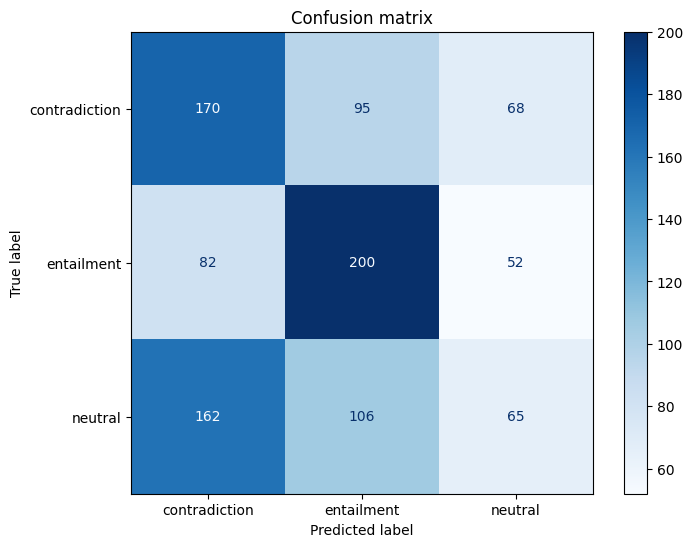

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d') 
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.savefig("../data/confusion_matrix.png", dpi=300)
plt.show()

## Confident error

In [ ]:
confident_error = df_result[
    (df_result['label'] != df_result['predicted_labels_text']) &
    (df_result['confidence_score'] > 0.7)
]
print("Number of confident error:", len(confident_error))
print("Ratio of confident error:", len(confident_error)/len(df_result))

Number of confident error: 172
Ratio of confident error: 0.172


In [62]:
confident_error.to_csv("../data/confident_error.csv", index=False)
print("Đã lưu lỗi sai với confidence cao vào data/confident_error.csv")

Đã lưu lỗi sai với confidence cao vào data/confident_error.csv


In [61]:
for index, row in confident_error.sample(n=7, random_state=42).iterrows():
    print('-'*50)
    print("Premise:", row["premise"])
    print("Hypothesis:", row["hypothesis"])
    print(f"True label: {row['label']} | Prediction: {row['predicted_labels_text']} | Confidence: {row['confidence_score']}")

--------------------------------------------------
Premise: Hủ tiếu ở đây gây ấn tượng vì luôn nóng sốt, ngậy mùi thơm của ngò gai và nước xương hầm.
Hypothesis: Hủ tiếu ở đây có hương vị ấn tượng.
True label: neutral | Prediction: entailment | Confidence: 0.8465596
--------------------------------------------------
Premise: Cụ thể, Talagon dài 5.152 mm, rộng 2.002 mm và cao 1.795 mm.
Hypothesis: Talagon là mẫu xe có kích thước rất lớn, chiều dài đến hơn 5m.
True label: neutral | Prediction: entailment | Confidence: 0.8005553
--------------------------------------------------
Premise: Hôm 29/4, trang SBS News, KPop Stars đưa tin luật được thông qua hai ngày trước đó, có hiệu lực đến năm 2025, nhằm hướng đến xây dựng gia đình lành mạnh.
Hypothesis: Hôm 29/4, trang SBS News, KPop Stars đưa tin luật có hiệu lực trong 3 năm, nhằm hướng đến xây dựng gia đình lành mạnh.
True label: neutral | Prediction: contradiction | Confidence: 0.7408364
--------------------------------------------------


In [53]:
cm_conf = confusion_matrix(confident_error['label'], confident_error['predicted_labels_text'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_conf, display_labels=target_names)

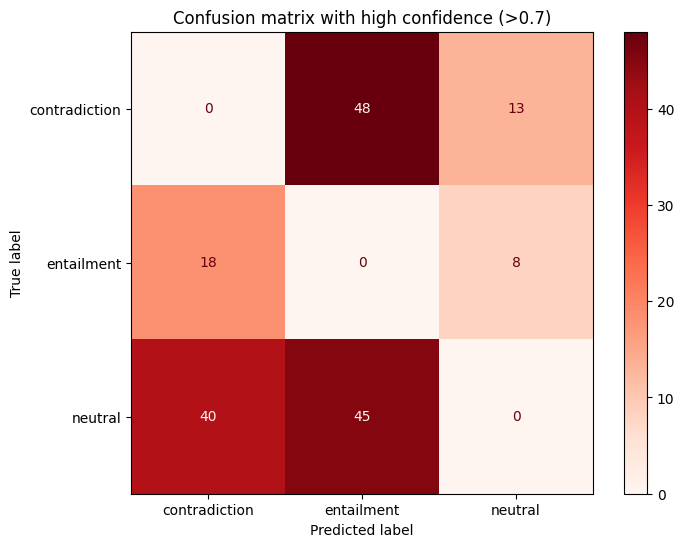

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Reds', ax=ax, values_format='d') 
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix with high confidence (>0.7)')
plt.savefig("../data/confident_confusion_matrix.png", dpi=300)
plt.show()

# Conclusion

## 1. Đánh giá Quá trình Huấn luyện (Learning Curves)

Quan sát biểu đồ **Loss chart in training progress** và **Score chart in validation set**, chúng ta có thể rút ra những kết luận quan trọng về trạng thái của mô hình Baseline:

* **Hiện tượng Overfitting nghiêm trọng:** Bắt đầu từ Epoch thứ 3, đường `Train Loss` liên tục cắm đầu đi xuống (tiến gần về 0.1), trong khi đường `Validation Loss` lại tăng vọt một cách tuyến tính (vượt mốc 2.0). Điều này minh chứng rõ ràng việc mô hình đang "học vẹt" (memorize) tập dữ liệu huấn luyện và mất đi khả năng tổng quát hóa trên dữ liệu mới.
* **Điểm dừng tối ưu (Early Stopping):** Nhìn sang biểu đồ Score, `Validation Accuracy` và `Macro F1` đạt đỉnh cao nhất ở Epoch số 4 (Accuracy ~0.47), sau đó tụt dần và đi ngang ở mức ~0.42. 
👉 **Đề xuất cải tiến:** Ở phiên bản sau, cần áp dụng cơ chế `EarlyStopping` tại khoảng Epoch 3-4, đồng thời tăng cường độ rớt mạng (Dropout rate) hoặc giảm Learning Rate để kìm hãm Overfitting.

## 2. Báo cáo Phân loại & Ma trận Nhầm lẫn (Confusion Matrix)

Với độ chính xác tổng thể (Accuracy) đạt **0.43** (cao hơn một chút so với xác suất đoán mò 0.33 của bài toán 3 nhãn), Baseline chưa thực sự hiểu được ngôn ngữ. Đi sâu vào chi tiết:

* **Nhãn Entailment (Kéo theo) dễ đoán nhất:** Đạt F1-score cao nhất (0.54) và Recall lên tới 0.60. Nhìn vào Confusion Matrix, trong 334 câu Entailment thực tế, mô hình đoán đúng được 200 câu.
* **Sự sụp đổ của nhãn Neutral (Trung lập):** Đây là điểm yếu "chí mạng" nhất của mô hình. F1-score chỉ đạt 0.25 và Recall chạm đáy ở mức 0.20. 
* **Định kiến (Bias) của mô hình:** Nhìn vào dòng `Neutral` của Ma trận nhầm lẫn, trong 333 câu trung lập thực tế, mô hình chỉ nhận diện đúng 65 câu. Thay vào đó, nó ép 162 câu thành `Contradiction` và 106 câu thành `Entailment`. Mô hình Baseline dường như có xu hướng "tránh né" việc đưa ra quyết định an toàn là Neutral, mà luôn cố gắng tìm kiếm sự liên quan hoặc mâu thuẫn một cách khiên cưỡng.

## 3. Phân tích Lỗi Hệ thống (Systematic Error Analysis)

Bằng cách lọc ra các dự đoán sai nhưng mô hình lại có độ tự tin cao (>0.7) từ tập `confident_error.csv`, chúng ta đã có thể "bắt mạch" được chính xác cách mô hình Baseline tư duy. Mô hình hoàn toàn không hiểu ngữ nghĩa logic sâu xa mà đang phụ thuộc vào các thủ thuật bề mặt (heuristics/shortcuts). 

Dưới đây là 3 "căn bệnh" điển hình nhất đã được trích xuất trực tiếp từ dữ liệu:

### a) Lỗ hổng Suy luận Toán học và Thời gian (Mathematical & Temporal Blindness)
Đây là điểm yếu "chí mạng" và thú vị nhất được phát hiện trong nhóm lỗi *Thực tế là Entailment nhưng mô hình tự tin phán Contradiction (18 lỗi)*. Mô hình ngôn ngữ chỉ khớp chuỗi ký tự mà không biết làm toán.
* **Toán học cộng trừ:** `Premise`: "Chỉ kiểm soát bóng 37%, Chelsea..." | `Hypothesis`: "Real kiểm soát bóng 63%...". Bất kỳ ai cũng tính được $100\% - 37\% = 63\%$ (Entailment), nhưng mô hình thấy hai số khác nhau nên vội vã đánh nhãn `Contradiction`.
* **Toán học nhân chia:** `Premise`: "Những con cú mèo nặng khoảng 100 g..." | `Hypothesis`: "Mười con cú mèo nặng 1k g." ($100g \times 10 = 1000g = 1kg$). Mô hình phán `Contradiction`.
* **Suy luận thời gian:** `Premise`: "...sự việc xảy ra đầu tháng 4 và được công bố sau hơn một tháng..." | `Hypothesis`: "Sự việc được công bố vào tháng 5.". ($Tháng 4 + 1 = Tháng 5$). Mô hình phán `Contradiction`.
* **Chuyển đổi hệ đo lường:** Chuyển từ "2-8 độ C" sang "35.6 - 46.4 độ F" cũng bị mô hình tự tin gán nhãn `Contradiction`.

### b) Sự nhầm lẫn Chủ thể - Khách thể (Subject-Object Swap)
Ở chiều ngược lại (*Thực tế là Contradiction nhưng phán Entailment*), mô hình bị lừa ngoạn mục bởi các câu đảo ngược cấu trúc chủ - vị ngữ.
* **Ví dụ:** `Premise`: "Nguyễn Thế Tài đột nhập nhà bà Trần Thị Mai Nhung... lấy đi hơn 500 triệu đồng." | `Hypothesis`: "Nhà của Nguyễn Thế Tài bị trộm vào nhà đánh cắp tài sản."
* **Phân tích:** Khách thể (bà Nhung) bị trộm, nhưng Hypothesis lại tráo đổi thành Chủ thể (Tài) bị trộm. Do các từ khóa (Tài, trộm, tài sản, nhà) xuất hiện y hệt nhau ở cả 2 câu, mô hình lười suy luận cấu trúc ngữ pháp và lập tức gán nhãn `Entailment` với độ tự tin cực cao.

### c) Bẫy ghép cặp số lượng sai lệch (Entity-Number Mismatch)
Mô hình đếm được từ, nhưng lại không hiểu từ đó bổ nghĩa cho danh từ nào.
* **Ví dụ:** `Premise`: "...Vinamilk đã hỗ trợ 45.000 hộp sữa cho hơn 800 trẻ em..." | `Hypothesis`: "...đã có hơn 45.000 trẻ em phải ăn tết xa nhà..."
* **Phân tích:** Mô hình thấy sự xuất hiện của số "45.000" và cụm "trẻ em" ở cả 2 câu nên tự tin dán nhãn `Entailment`. Nó hoàn toàn mù tịt trước việc số lượng đã bị gán nhầm đối tượng (45.000 hộp sữa $\neq$ 45.000 trẻ em). Tương tự cho câu "hơn 2 tuần" và "chưa tới 10 ngày", mô hình gán `Entailment` bất chấp sự phi logic về mặt thời lượng.

👉 **KẾT LUẬN & HƯỚNG CẢI TIẾN:** Mô hình Baseline (PhoBERT) hiện đang hoạt động theo cơ chế **"Khớp từ vựng" (Lexical Matching)** thay vì **"Đ